<a href="https://colab.research.google.com/github/i-malur/bootcamp-data-analytics-mod7/blob/main/mod7_estat%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Frequência e medidas

In [28]:
# bibliotecas base
import pandas as pd
import numpy as np
# bibliotecas para visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
# biblioteca para estatística
import scipy.stats as stat

## Leitura dos dados

In [29]:
!pip install pydataset --quiet

In [30]:
from pydataset import data

## Leitura do dataset

dataset Forbes2000

ranking das principais empresas de 2004. Contém 8 variáveis e 2000 observações (linhas):
* rank - o ranking da empresa;
* name - o nome da empresa;
* country - o pais da empresa;
* category - a categoria dos produtos que a empresa produz;
* sales - as vendas da empresa [em bilhões de dólares];
* profits - os lucros da empresa [em bilhões de dólares];
* assets - os ativos da empresa [em bilhões de dólares];
* marketvalue - o valor da empresa no mercado [em bilhões de dólares];



In [31]:
data('Forbes2000', show_doc = True)

Forbes2000

PyDataset Documentation (adopted from R Documentation. The displayed examples are in R)

##  The Forbes 2000 Ranking of the World's Biggest Companies (Year 2004)

### Description

The Forbes 2000 list is a ranking of the world's biggest companies, measured
by sales, profits, assets and market value.

### Usage

    data("Forbes2000")

### Format

A data frame with 2000 observations on the following 8 variables.

rank

the ranking of the company.

name

the name of the company.

country

a factor giving the country the company is situated in.

category

a factor describing the products the company produces.

sales

the amount of sales of the company in billion USD.

profits

the profit of the company in billion USD.

assets

the assets of the company in billion USD.

marketvalue

the market value of the company in billion USD.

### Source

http://www.forbes.com, assessed on November 26th, 2004.

### Examples

    data("Forbes2000", package = "HSAUR")
    summary(Forbes2000)


In [32]:
forbes = data('Forbes2000')

In [33]:
forbes.head()

,rank,name,country,category,sales,profits,assets,marketvalue
1,1,Citigroup,United States,Banking,94.71,17.85,1264.03,255.30
2,2,General Electric,United States,Conglomerates,134.19,15.59,626.93,328.54
3,3,American Intl Group,United States,Insurance,76.66,6.46,647.66,194.87
4,4,ExxonMobil,United States,Oil & gas operations,222.88,20.96,166.99,277.02
5,5,BP,United Kingdom,Oil & gas operations,232.57,10.27,177.57,173.54


### Verificando os tipos de dados:

Categóricas nominais:
* name

Categóricas ordinais (neste podemos considerar as duas variáveis como ordinais, pois, possuem um agrupamento):
* country
* category

Numéricas discretas:
* rank

Numéricas contínuas:
* sales
* profits
* assets
* marketvalue


In [34]:
forbes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 1 to 2000
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rank         2000 non-null   int64  
 1   name         2000 non-null   object 
 2   country      2000 non-null   object 
 3   category     2000 non-null   object 
 4   sales        2000 non-null   float64
 5   profits      1995 non-null   float64
 6   assets       2000 non-null   float64
 7   marketvalue  2000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 140.6+ KB


## Análise de tendência central

Moda: aplicada e, todas as variáveis do dataframe
* df.mode()
* Neste caso, vamos retirar as duas primeira colunas, pois, el

In [35]:
forbes.iloc[:, 2:8].mode() # todas as linhas e pegamos a coluna do index 2 até index 8

,country,category,sales,profits,assets,marketvalue
0,United States,Banking,0.58,0.13,4.22,1.34


In [36]:
forbes[['sales', 'profits', 'assets', 'marketvalue']].mean()

,0
sales,9.697010
profits,0.381133
assets,34.041850
marketvalue,11.877655


In [37]:
forbes[['sales', 'profits', 'assets', 'marketvalue']].median()

,0
sales,4.365
profits,0.200
assets,9.345
marketvalue,5.150


describe() calcula estatísticas descritivas das variáveis numéricas

In [38]:
forbes.describe()

,rank,sales,profits,assets,marketvalue
count,2000.000000,2000.000000,1995.000000,2000.000000,2000.000000
mean,1000.500000,9.697010,0.381133,34.041850,11.877655
std,577.494589,18.002592,1.765454,99.678786,24.460197
min,1.000000,0.010000,-25.830000,0.270000,0.020000
25%,500.750000,2.017500,0.080000,4.025000,2.720000
50%,1000.500000,4.365000,0.200000,9.345000,5.150000
75%,1500.250000,9.547500,0.440000,22.792500,10.602500
max,2000.000000,256.330000,20.960000,1264.030000,328.540000


A média e mediana nesse caso é representada pelo percentil 50%

### Para a análise de dispersão iremos calcular:

Amplitude, desvio padrao e variancia  
Analisar os histogramas das variaveis  
Construir o boxplot  
Verificar outliers  

In [39]:
# função para adicionar no describe anterior a amplitude e variância
# amplitude -> máximo - mínimo
# variância -> desvio padrão ao quadrado
# std -> padrão
def describe_new(df):
  df1 = df.describe()
  df1.loc['amplitude'] = df1.loc['max'] - df1.loc['min']
  df1.loc['variancia'] = df1.loc['std'] * df1.loc['std']
  return df1

In [40]:
describe_new(forbes)

,rank,sales,profits,assets,marketvalue
count,2000.000000,2000.000000,1995.000000,2000.000000,2000.000000
mean,1000.500000,9.697010,0.381133,34.041850,11.877655
std,577.494589,18.002592,1.765454,99.678786,24.460197
min,1.000000,0.010000,-25.830000,0.270000,0.020000
25%,500.750000,2.017500,0.080000,4.025000,2.720000
50%,1000.500000,4.365000,0.200000,9.345000,5.150000
75%,1500.250000,9.547500,0.440000,22.792500,10.602500
max,2000.000000,256.330000,20.960000,1264.030000,328.540000
amplitude,1999.000000,256.320000,46.790000,1263.760000,328.520000
variancia,333500.000000,324.093331,3.116828,9935.860339,598.301217


* Maior amplitude: está relacionada ao valor dos ativos das empresas, assets. Essa variável também possui o maior desvio padrão.

#### Histogramas

<Figure size 800x1000 with 0 Axes>

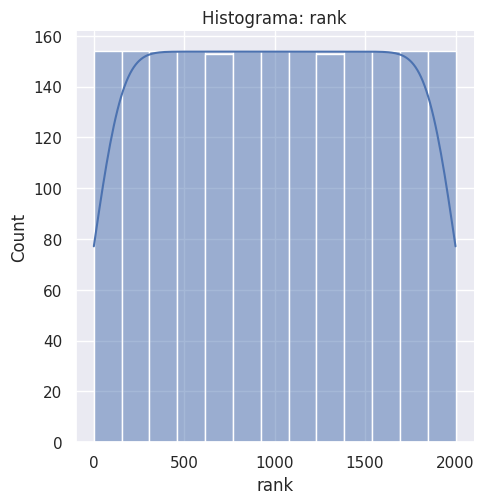

<Figure size 800x1000 with 0 Axes>

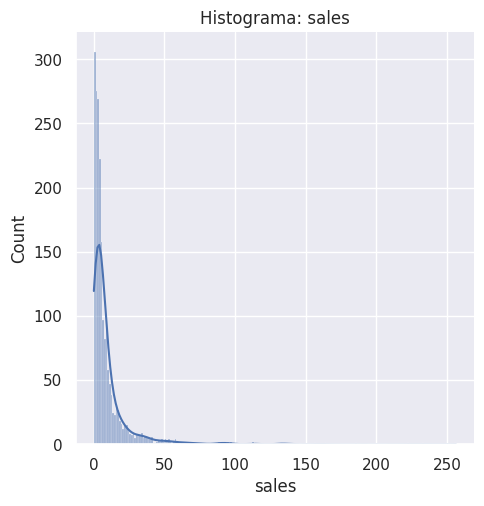

<Figure size 800x1000 with 0 Axes>

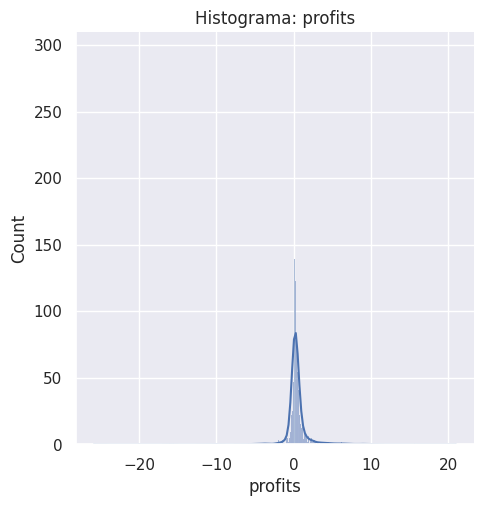

<Figure size 800x1000 with 0 Axes>

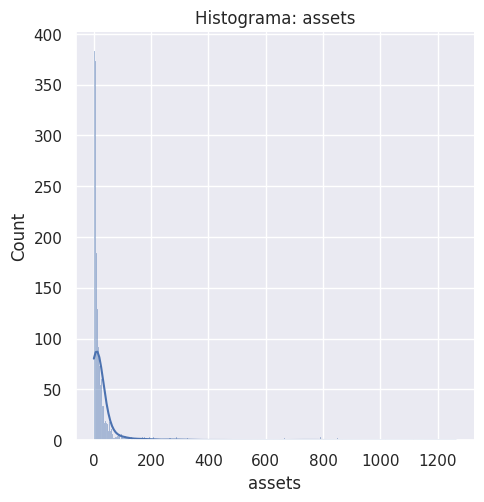

<Figure size 800x1000 with 0 Axes>

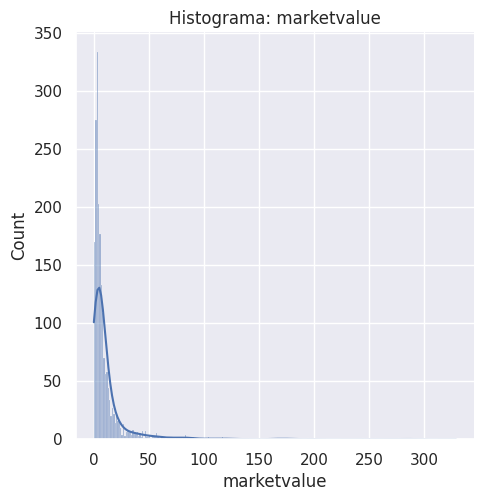

In [41]:
plt.rcParams['figure.figsize'] = [8, 10]
sns.set_theme()

for column in forbes.select_dtypes(include = np.number).columns:
  plt.figure()
  sns.displot(data = forbes, x = column, kde = True)
  plt.title('Histograma: ' + column)

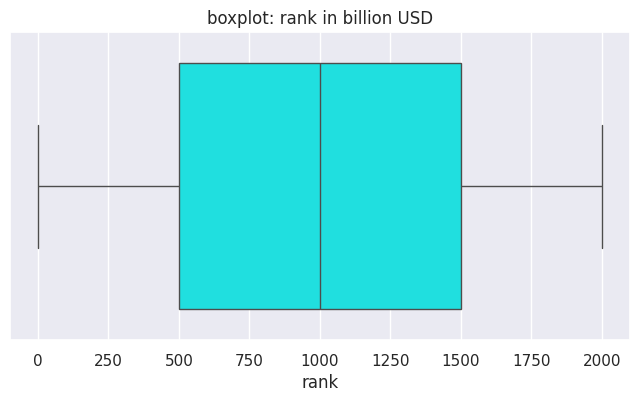

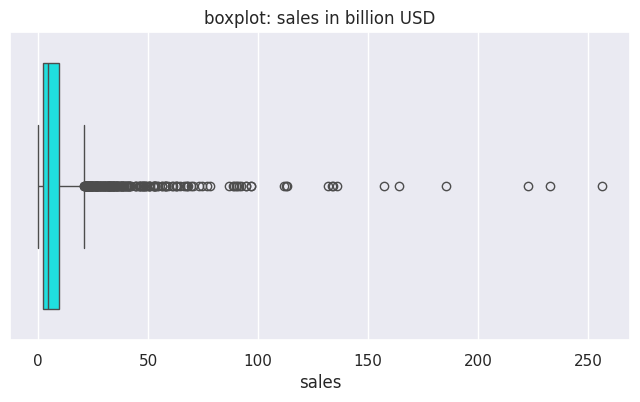

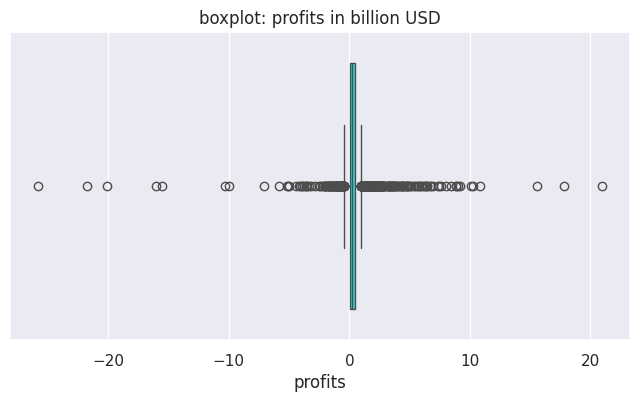

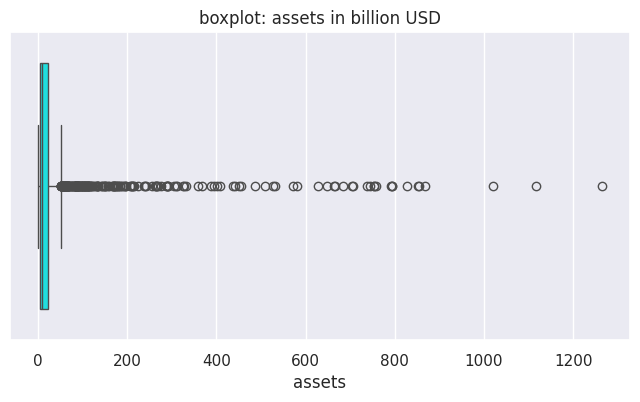

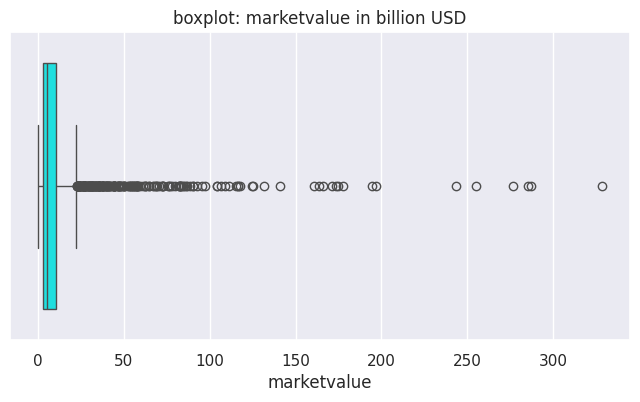

In [42]:
plt.rcParams['figure.figsize'] = [8, 4]
sns.set_theme()

# para cada uma das colunas numéricas, roda o boxplot
for column in forbes.select_dtypes(include=np.number).columns:
  plt.figure()
  sns.boxplot(data = forbes, x = column, color='cyan', showfliers=True)
  plt.title('boxplot: ' + column + ' in billion USD')

Grande quantidade de outliers expressados pelos pontos nos gráficos de caixa. Podemos fazer uma visualização sem considerar os outliers utilizando showfliers=False.

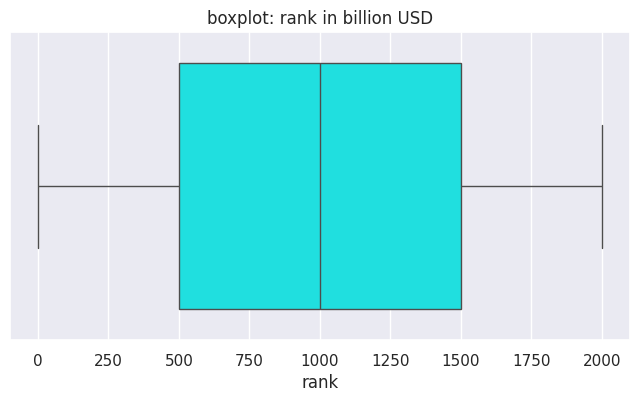

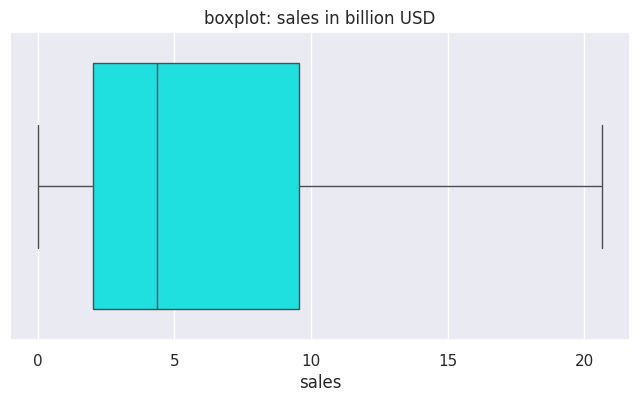

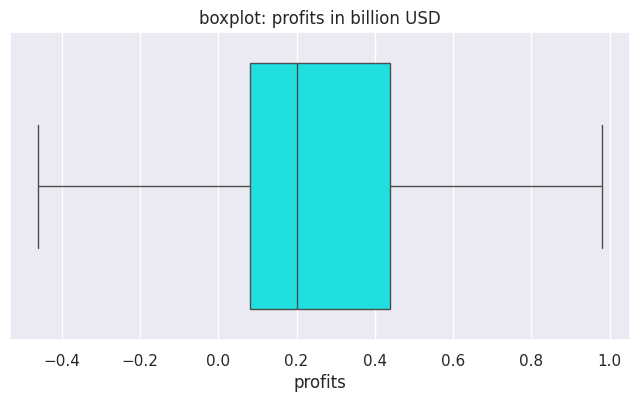

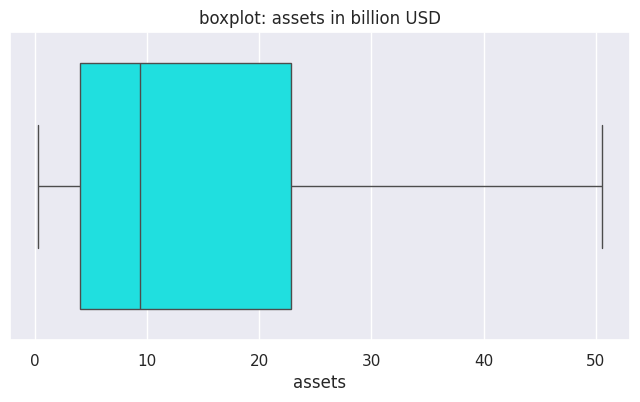

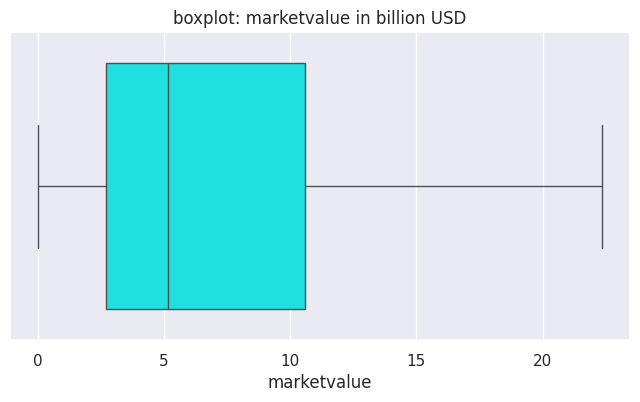

In [43]:
plt.rcParams['figure.figsize'] = [8, 4]
sns.set_theme()

# para cada uma das colunas numéricas, roda o boxplot
for column in forbes.select_dtypes(include=np.number).columns: # filtrando apenas as colunas numéricas
  plt.figure()
  sns.boxplot(data = forbes, x = column, color='cyan', showfliers=False)
  plt.title('boxplot: ' + column + ' in billion USD')

Análise dos gráficos
* Vendas próximas de 2-9 bilhões
* Oscilação do lucro a 0 (0.1 a 0.5 bilhões) com valores positivos e negativos nas caudas.
* Ativos (assets) de 5 a 25 bilhões
* Valor de mercado próximo a 3 - 11 bilhões

### Outliers

z-score: método que utiliza como referência a quantos desvios padrões a informação está da média.

Se z-score > 3 desvios, pode-se considerar que o valor é outlier

In [44]:
def find_outlier_zscore(dataset, threshold, colname):
  # função que calcula a quantidade de outliers encontrados dado o nome do dataframe, o threshold e nome da coluna

  df = dataset[colname]
  outliers = []
  zscore = []
  threshold = threshold

  # cálculo da média e desvio padrão
  mean = np.mean(df)
  std = np.std(df)

  for i in df.values:

    # passa por cada valor da coluna e aplica a fórmula do zscore e armazenando na lista z_score
    z_score = (i - mean) / std
    zscore.append(z_score)

    # threshold 3
    # np.abs() remove o sinal de - caso o número da lista z_score seja muito abaixo da média
    # se a distância for maior que 3 desvios, o número orginal é armazenado a lista de outliers
    if np.abs(z_score) > threshold:
      outliers.append(i)

  # No final, ela dá um print com o total encontrado e devolve as duas listas preenchidas para quem a chamou.
  print(f'O número de outliers encontrados em {colname} foi de: ', len(outliers))
  return zscore, outliers

O número de outliers encontrados em rank foi de:  0
O número de outliers encontrados em sales foi de:  35
O número de outliers encontrados em profits foi de:  38
O número de outliers encontrados em assets foi de:  38
O número de outliers encontrados em marketvalue foi de:  36


<Figure size 1000x500 with 0 Axes>

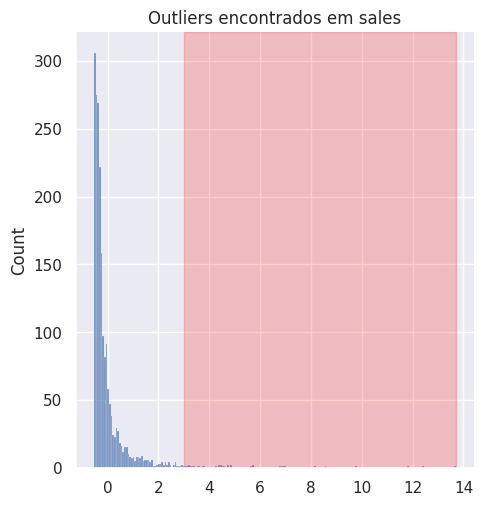

<Figure size 1000x500 with 0 Axes>

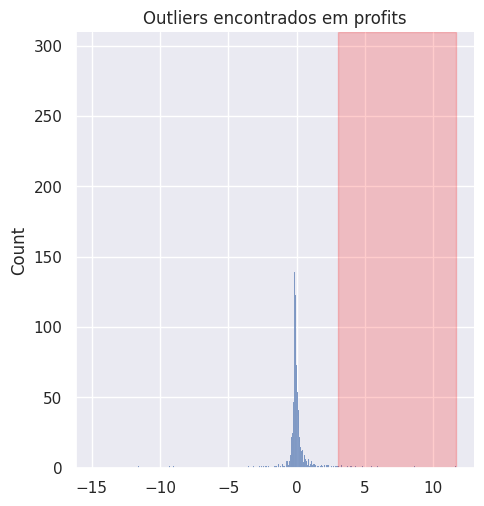

<Figure size 1000x500 with 0 Axes>

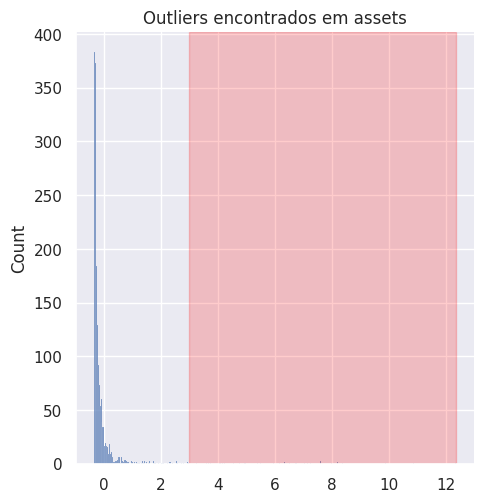

<Figure size 1000x500 with 0 Axes>

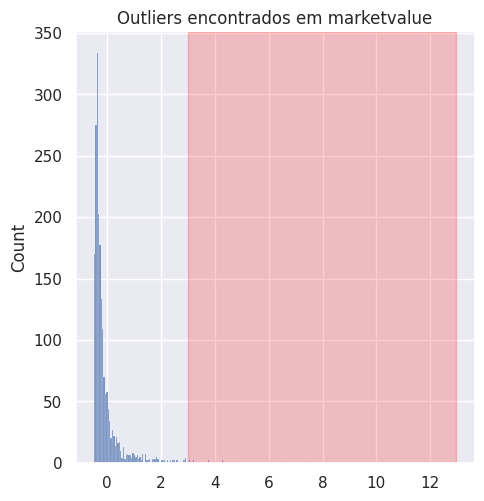

In [45]:
for column in forbes.select_dtypes(include=np.number).columns:
  zscore, out = find_outlier_zscore(forbes, 3, column)
  if len(out) > 3:
    plt.figure(figsize = (10,5))
    sns.displot(zscore)
    plt.axvspan(xmin = 3, xmax = max(zscore), alpha=0.2, color='red')
    plt.title(f'Outliers encontrados em {column}')

# média de empresas outliers - 35 para mais

#### Removendo outliers

##### ZSCORE

In [47]:
# apenas com limite acima de 3 desvios, mas podemos fazer abaixo de 3 desvios também

def replace_nan_outlier_zscore(dataset, threshold, colname):
  # funcao que faz um replace para NaN (valor nulo) caso seja encontrado um outlier
    df = dataset[colname]
    outliers = []
    zscore = []
    val = []

    threshold = threshold
    mean = np.mean(df)
    std = np.std(df)

    for i in df.values:
      z_score= (i - mean)/std
      zscore.append(z_score)
      if np.abs(z_score) > threshold:
          outliers.append(i)
          val.append(np.nan) # se for outlier, o valor é salvo nessa lista como NaN
      else:
          val.append(i) # se não for outlier, o valor é salvo normalmente

    return val

In [48]:
def drop_outliers(dataset, threshold):
  # vamos utilizar a funcao drop NA para remover outliers
  # para cada coluna, vamos rodar a função acima e fazemos a substituição da coluna pela coluna com valores outliers NaN e os valores normais
  for column in dataset.select_dtypes(include=np.number).columns:
    dataset[column] =  replace_nan_outlier_zscore(dataset, 3, column)
  return dataset.dropna() # retirando NaN

In [54]:
def replace_median_outliers(dataset, threshold):
  # vamos utilizar a funcao fillna para trocar os NaNs pela mediana
  # para cada coluna, vamos rodar a função acima e fazemos a substituição da coluna pela coluna com valores outliers NaN e os valores normais
  for column in dataset.select_dtypes(include=np.number).columns:
    dataset[column] =  replace_nan_outlier_zscore(dataset, 3, column)
  return dataset.fillna(dataset.median(numeric_only=True)) # trocando NaN pela mediana

In [55]:
forbes_zscore_na = drop_outliers(forbes, 3)

In [56]:
forbes_zscore_na

,rank,name,country,category,sales,profits,assets,marketvalue
140,140,Cendant,United States,Hotels restaurants & leisure,17.49,1.42,41.07,23.08
171,171,Chubu Electric Power,Japan,Utilities,18.41,0.90,52.08,15.59
173,173,Exelon,United States,Utilities,15.81,0.79,41.62,21.44
175,175,BCE,Canada,Telecommunications services,14.70,1.40,30.35,20.20
176,176,HCA,United States,Health care equipment & services,21.81,1.33,21.06,21.65
...,...,...,...,...,...,...,...,...
1996,1996,Siam City Bank,Thailand,Banking,0.48,0.02,11.27,1.47
1997,1997,Yokogawa Electric,Japan,Business services & supplies,2.78,-0.22,2.96,3.29
1998,1998,Hindalco Industries,India,Materials,1.35,0.14,2.47,2.76
1999,1999,Nexans,France,Capital goods,5.09,0.00,2.71,0.88


In [57]:
forbes_zscore_median = replace_median_outliers(forbes, 3)

In [58]:
forbes_zscore_median

,rank,name,country,category,sales,profits,assets,marketvalue
1,1,Citigroup,United States,Banking,3.785,0.18,7.73,4.41
2,2,General Electric,United States,Conglomerates,3.785,0.18,7.73,4.41
3,3,American Intl Group,United States,Insurance,3.785,0.18,7.73,4.41
4,4,ExxonMobil,United States,Oil & gas operations,3.785,0.18,7.73,4.41
5,5,BP,United Kingdom,Oil & gas operations,3.785,0.18,7.73,4.41
...,...,...,...,...,...,...,...,...
1996,1996,Siam City Bank,Thailand,Banking,0.480,0.02,11.27,1.47
1997,1997,Yokogawa Electric,Japan,Business services & supplies,2.780,-0.22,2.96,3.29
1998,1998,Hindalco Industries,India,Materials,1.350,0.14,2.47,2.76
1999,1999,Nexans,France,Capital goods,5.090,0.00,2.71,0.88


##### IQR

O método IQR (distância inter-quartil em inglês) ve a distancia da amplitude dos quartis:


In [66]:
forbes = data('Forbes2000')

In [67]:
def find_outlier_iqr(dataset, colname):
  q25, q75 = np.quantile(dataset[colname], 0.25), np.quantile(dataset[colname], 0.75)

  # calcula IQR
  iqr = q75 - q25

  # calcula outlier cutoff
  cut_off = iqr * 1.5

  # calcula margens inferiores, lower e superiores upper
  lower, upper = q25 - cut_off, q75 + cut_off
  print(' IQR é ',iqr)
  outliers = []

  # verifica se cada valor é maior que o limite superior ou menor que o limite inferior
  for i in dataset[colname].values:
    if((i > upper)or(i < lower)):
      outliers.append(i)
  print('O numero de outliers encontrado foi de', len(outliers))
  return lower, upper, outliers

 IQR é  999.5
O numero de outliers encontrado foi de 0
 IQR é  7.529999999999999
O numero de outliers encontrado foi de 212
 IQR é  nan
O numero de outliers encontrado foi de 0
 IQR é  18.7675
O numero de outliers encontrado foi de 222
 IQR é  7.8824999999999985
O numero de outliers encontrado foi de 217


<Figure size 1000x600 with 0 Axes>

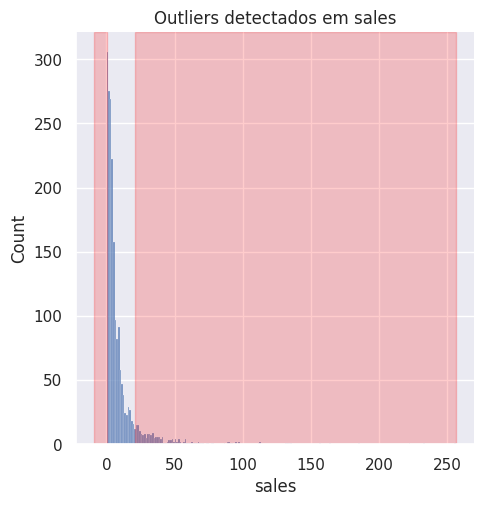

<Figure size 1000x600 with 0 Axes>

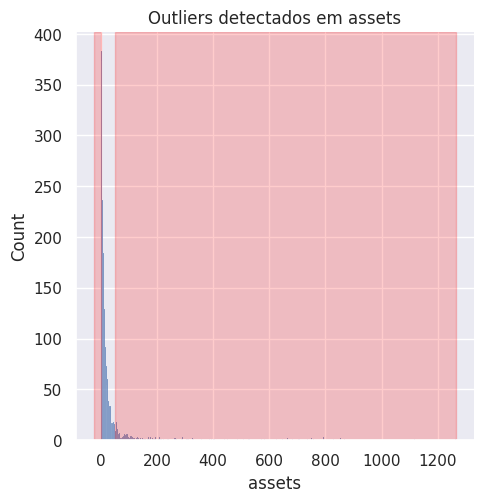

<Figure size 1000x600 with 0 Axes>

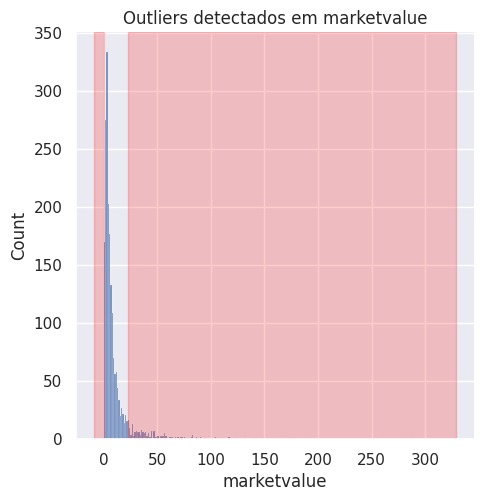

In [68]:
for column in forbes.select_dtypes(include=np.number).columns:
  lower, upper, out =  find_outlier_iqr(forbes, column)
  if (len(out) > 0):
    plt.figure(figsize = (10,6))
    sns.displot(forbes[column], kde=False)
    plt.axvspan(xmin = lower,xmax= forbes[column].min(),alpha=0.2, color='red')
    plt.axvspan(xmin = upper,xmax= forbes[column].max(),alpha=0.2, color='red')
    plt.title("Outliers detectados em {}".format(column))

### Análise de dados faltantes

1. Verificar a soma de dados faltantes para cada uma das colunas

In [69]:
forbes.isna().sum()

,0
rank,0
name,0
country,0
category,0
sales,0
profits,5
assets,0
marketvalue,0


In [70]:
import missingno as msno # pacote com visualizações de dados faltantes

<Axes: >

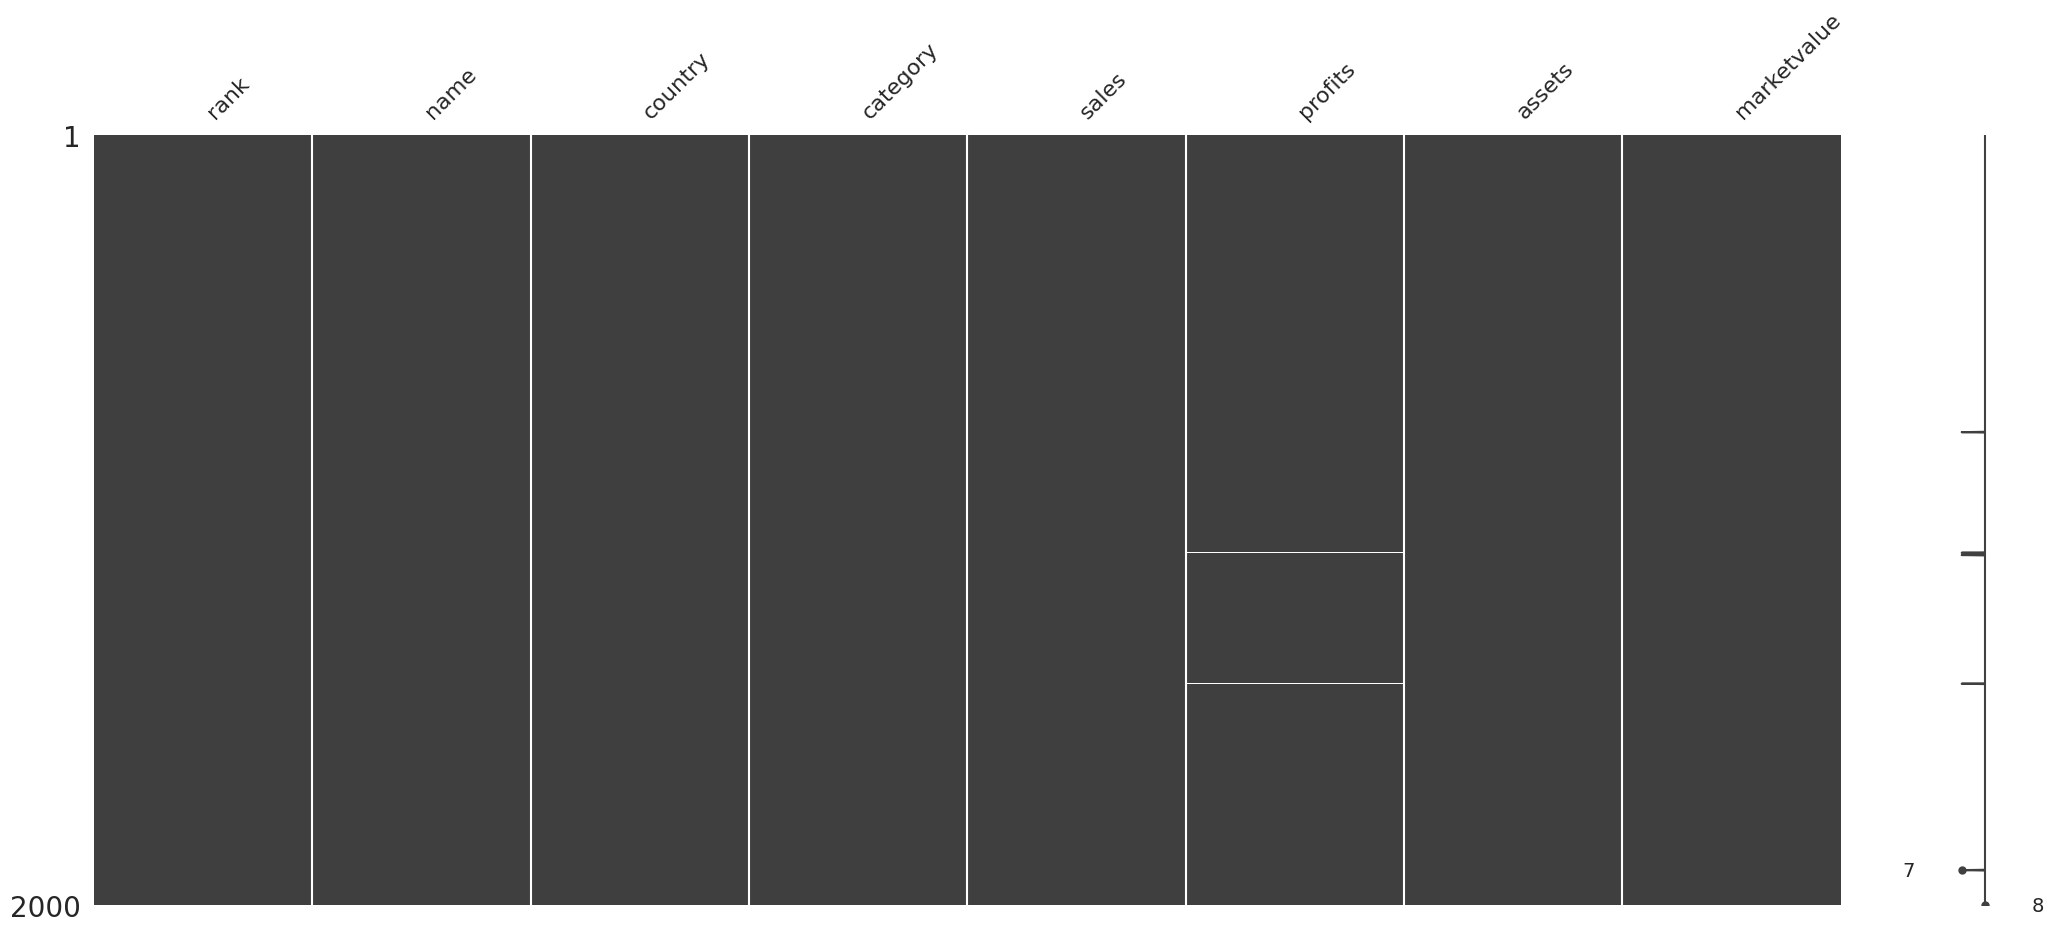

In [71]:
msno.matrix(forbes) # cada linha branca é um dado faltante

isna() é a mesma coisa de isnull() no pandas

In [73]:
# tabela com o % de valores faltantes de cada variável

missing = forbes.isna().sum()

missing_perc = 100 * forbes.isna().sum() / len(forbes) # multiplica por 100 e divide pelo total de linhas do dataframe

mis_val_table = pd.concat([missing, missing_perc], axis=1) # número de valores e % de valores faltantes

mis_val_table = mis_val_table.rename(columns = {0 : 'Count: valores nulos', 1 : '% do Total'})

mis_val_table = mis_val_table[mis_val_table.iloc[:,1] != 0].sort_values(
        '% do Total', ascending=False).round(1)

print ("O dataframe contém " + str(forbes.shape[1]) + " colunas.\n"
            "Contendo " + str(mis_val_table.shape[0]) +
              " colunas com valores faltantes.")

mis_val_table

O dataframe contém 8 colunas.
Contendo 1 colunas com valores faltantes.


,Count: valores nulos,% do Total
profits,5,0.2


## EDA Automatizada

Existem 2 pacotes famosos no mundo da analise de dados que fazem analises exploratorias automatizadas:

1. Pandas profiling -> chamado atualmente de ydataprofiling
2. Sweetviz


Ambas geram relatorios html prontos para analises / interpretacoes do analista

In [74]:
!pip install sweetviz --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 73.8 MB/s eta 0:00:00


In [75]:
import sweetviz as sv

my_report = sv.analyze(forbes) # le os dados e cria uma report

                                             |          | [  0%]   00:00 -> (? left)


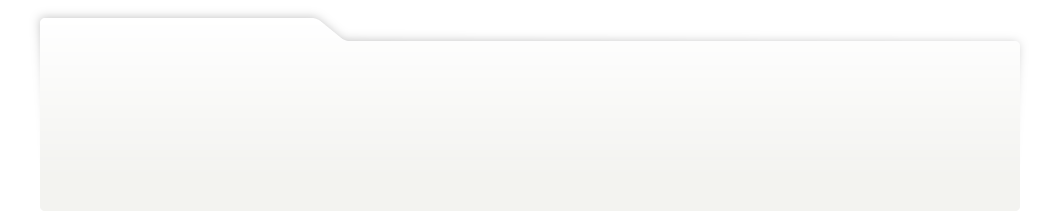
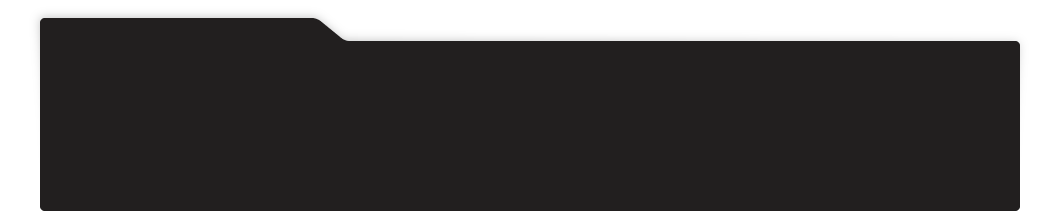
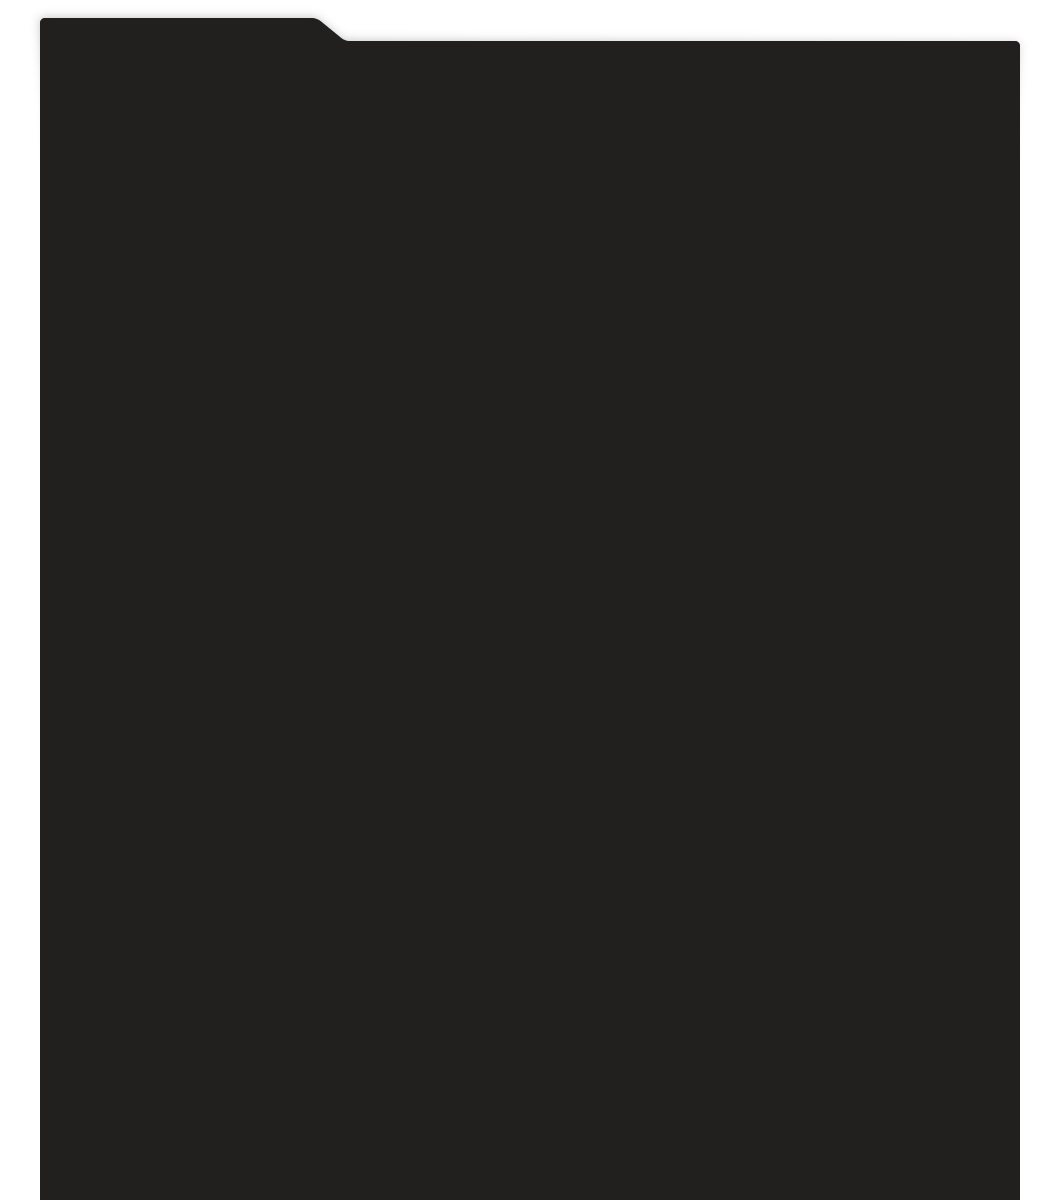
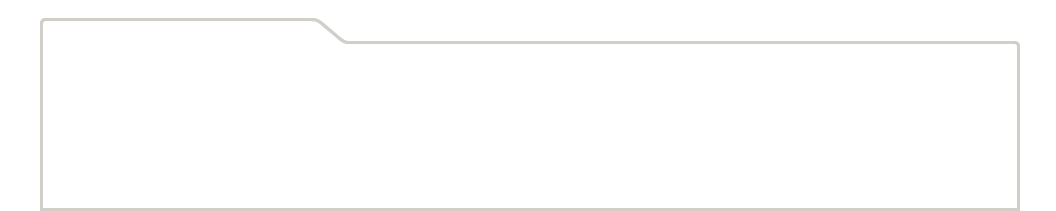
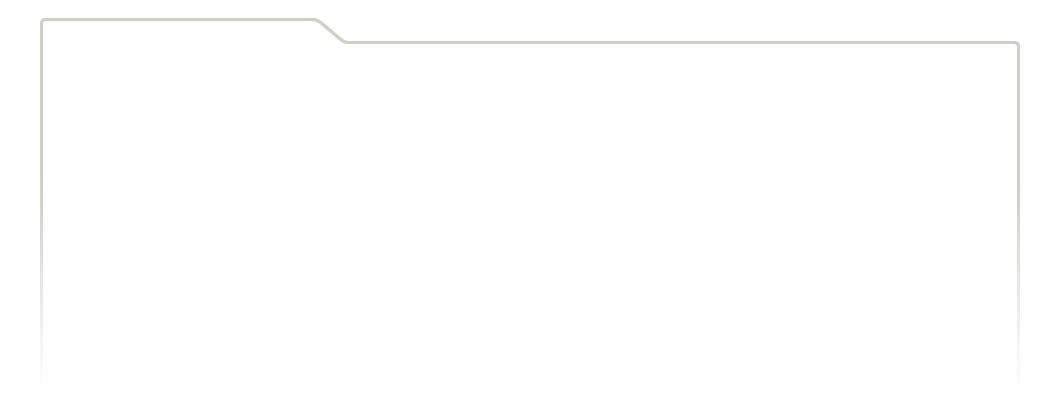
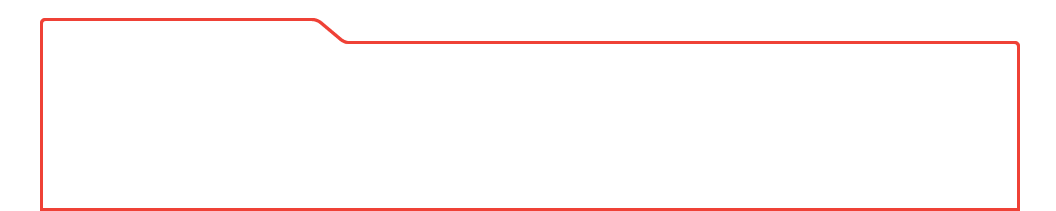
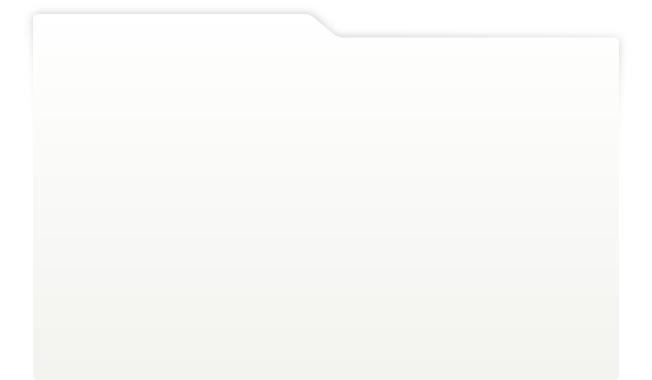
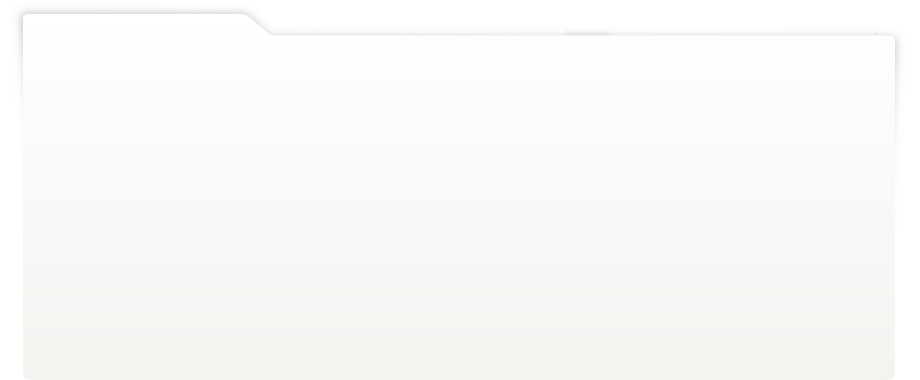
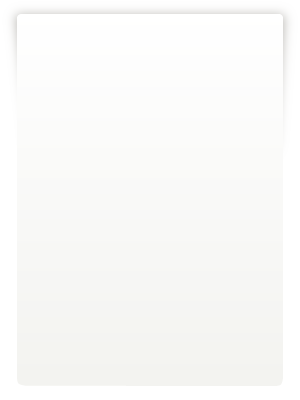
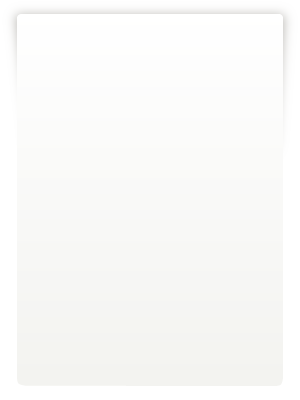
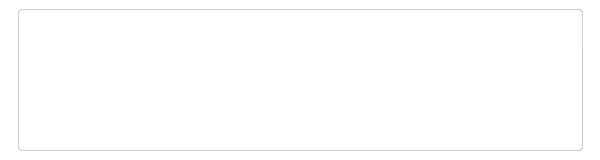
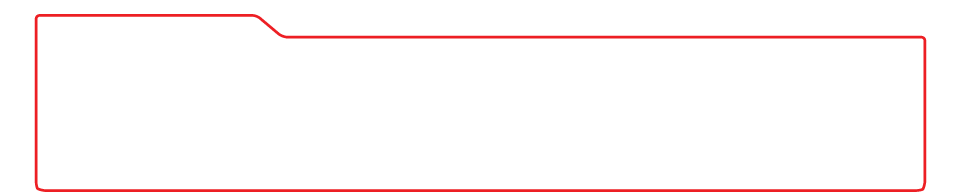
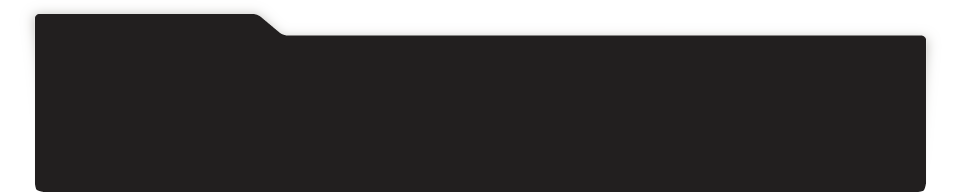
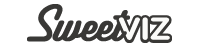
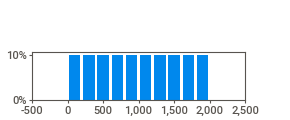
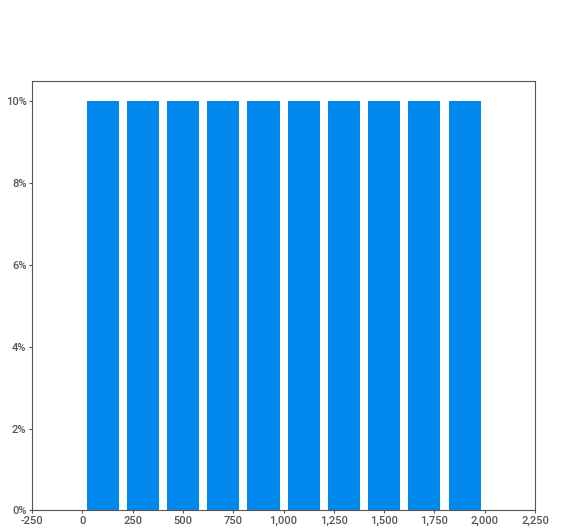
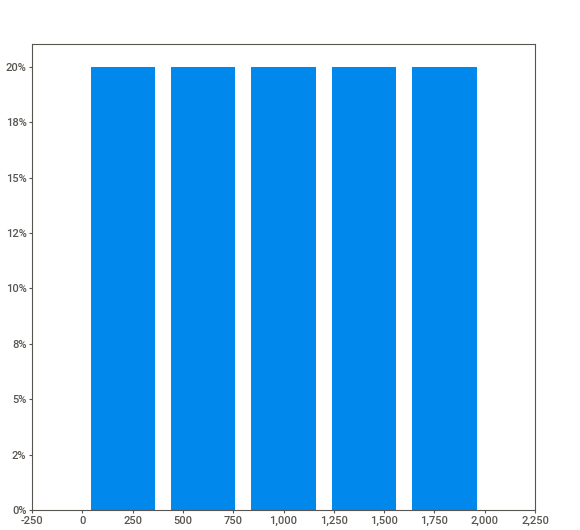
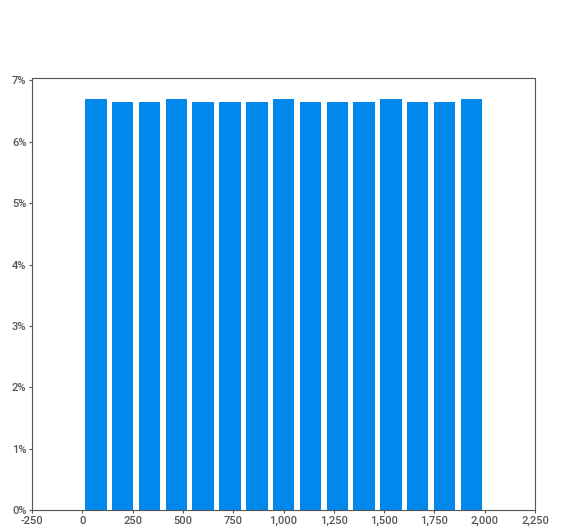
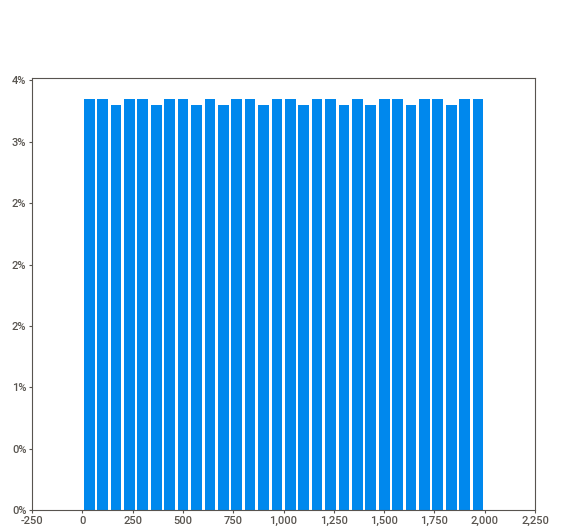
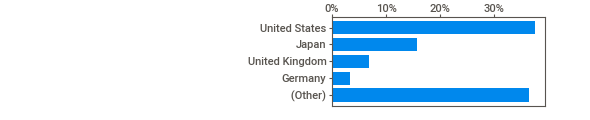
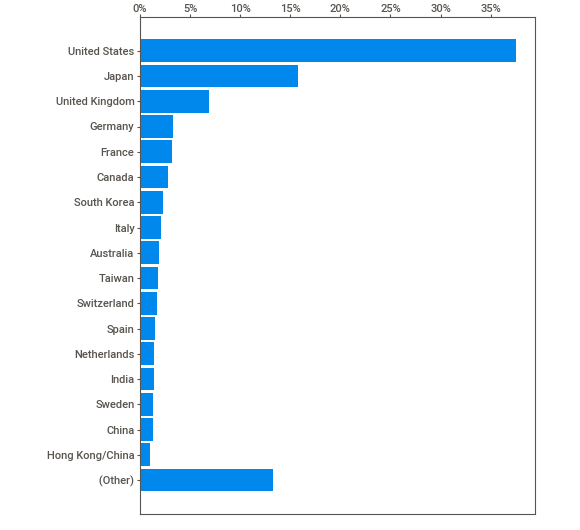
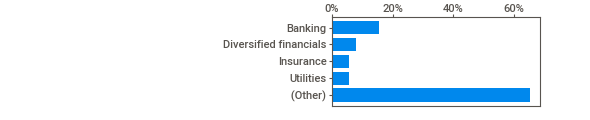
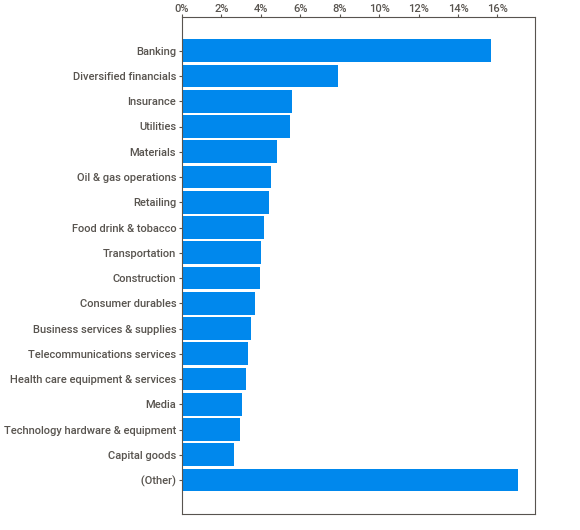
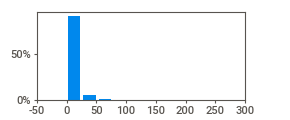
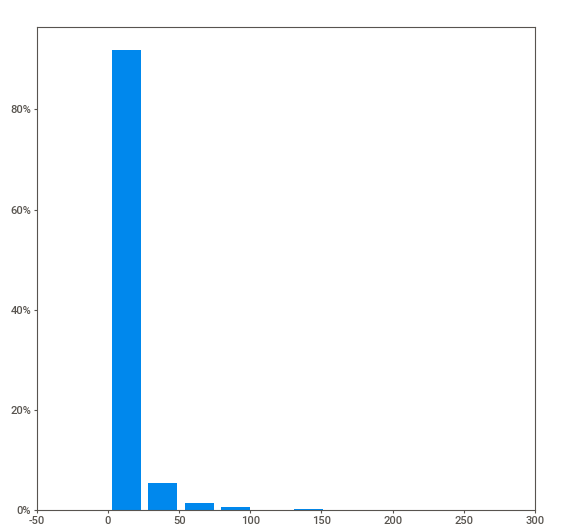
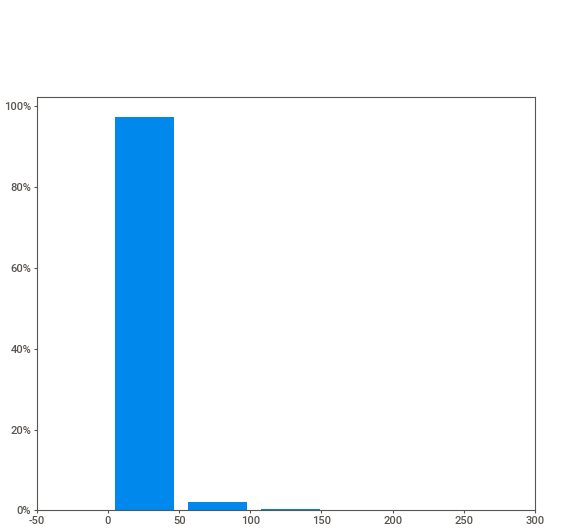
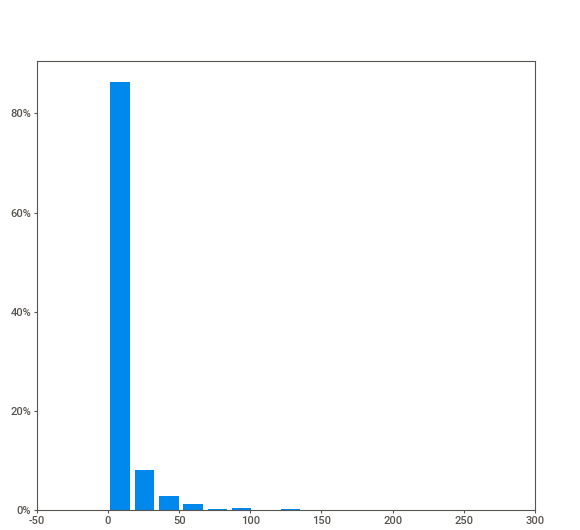
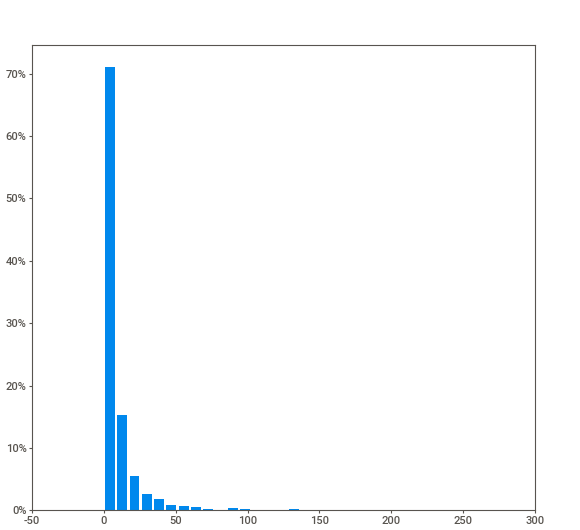
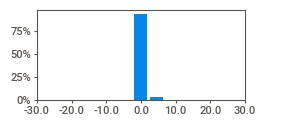
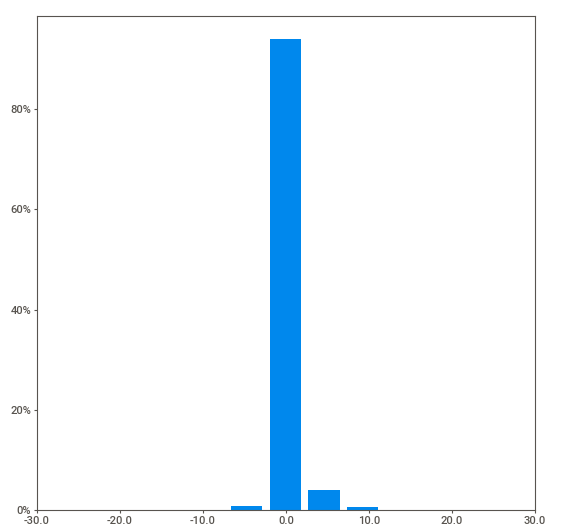
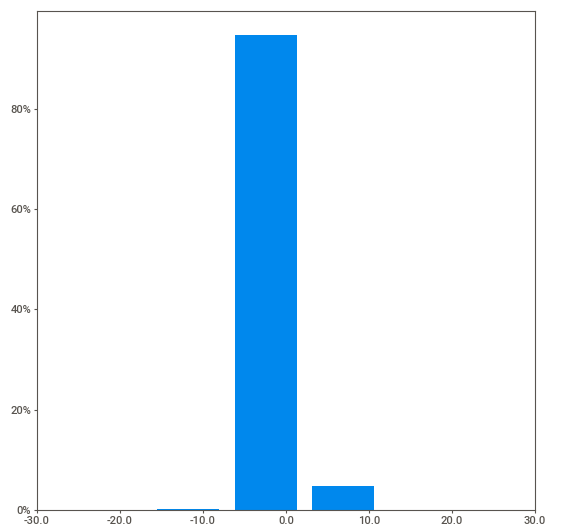
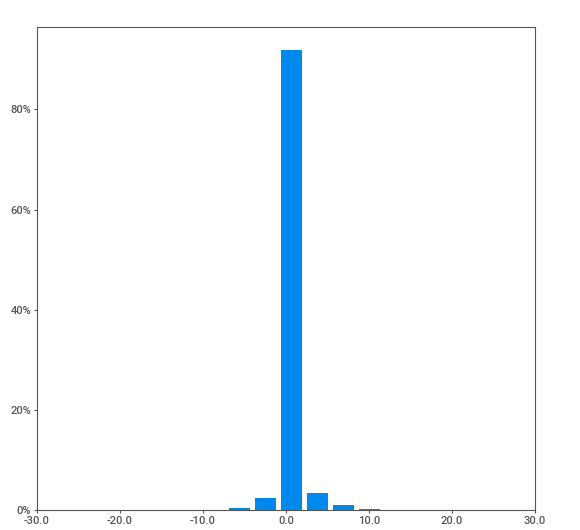
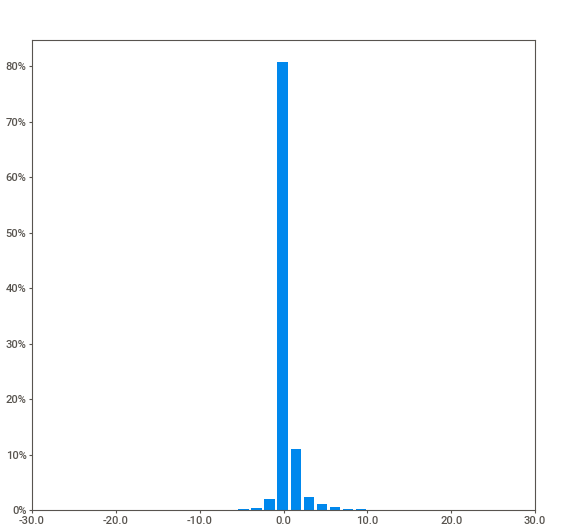
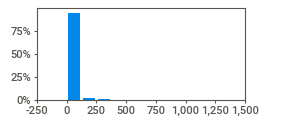
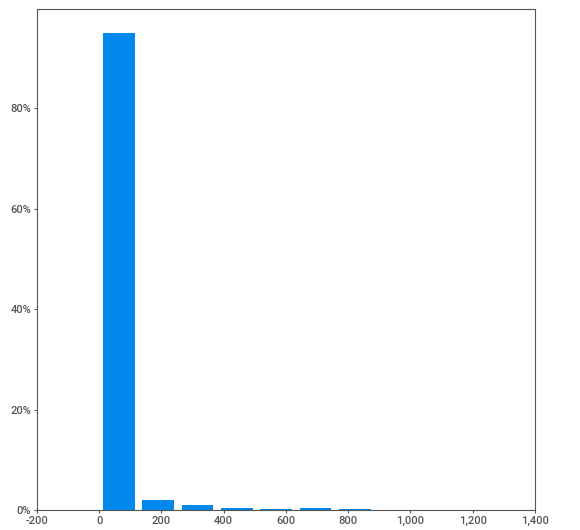
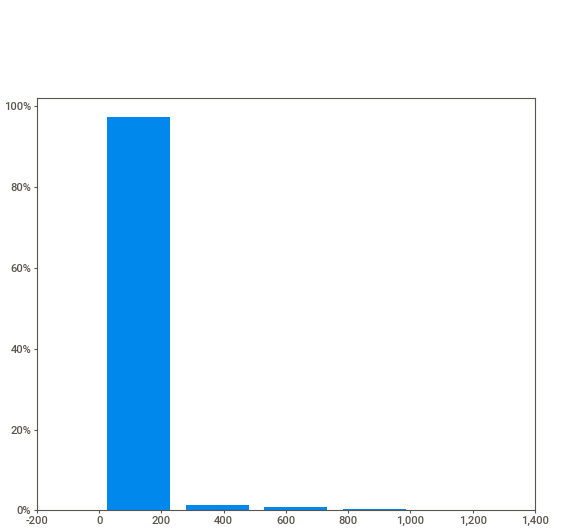
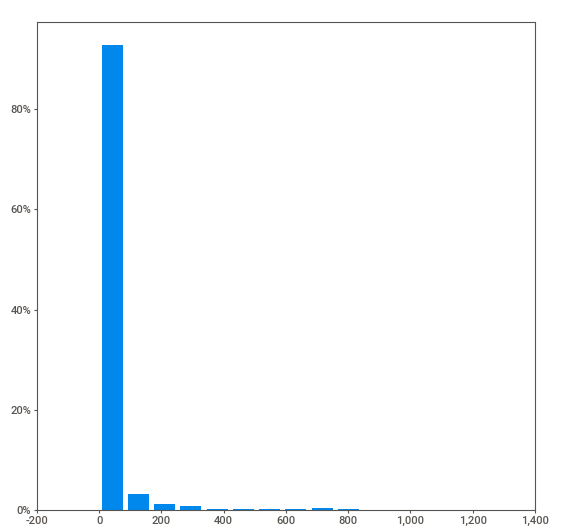
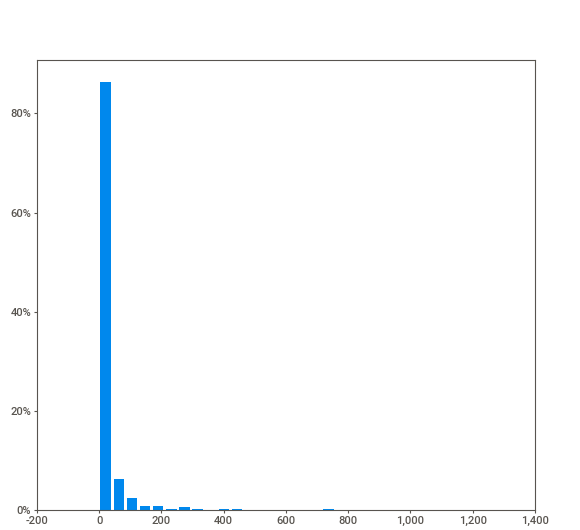
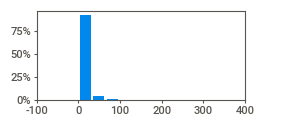
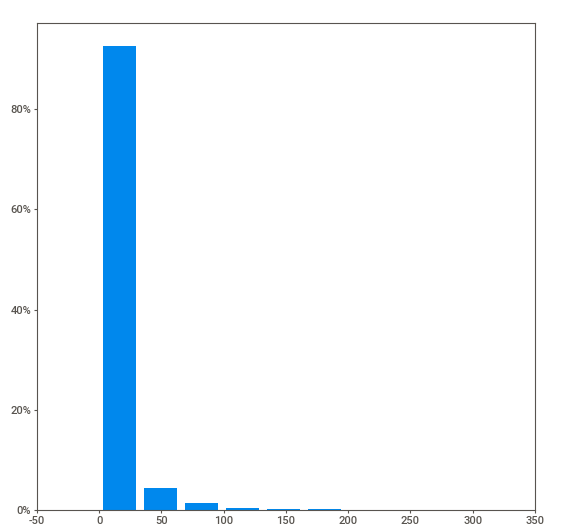
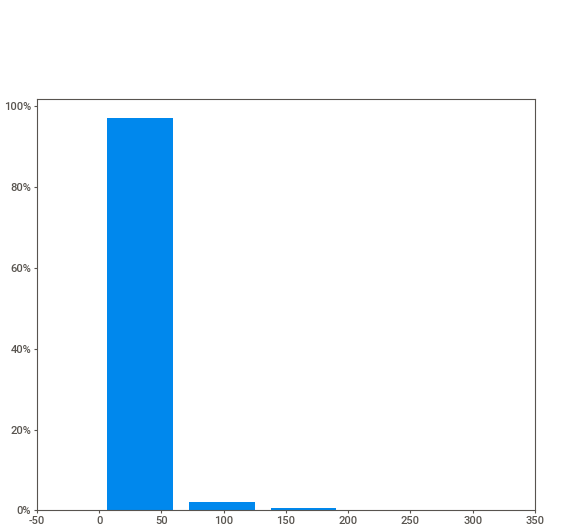
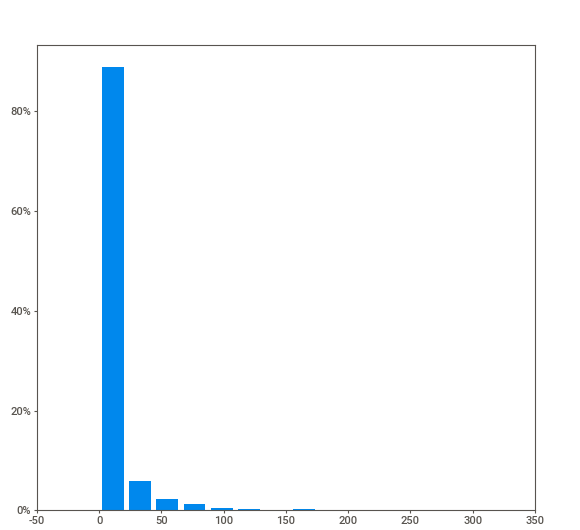
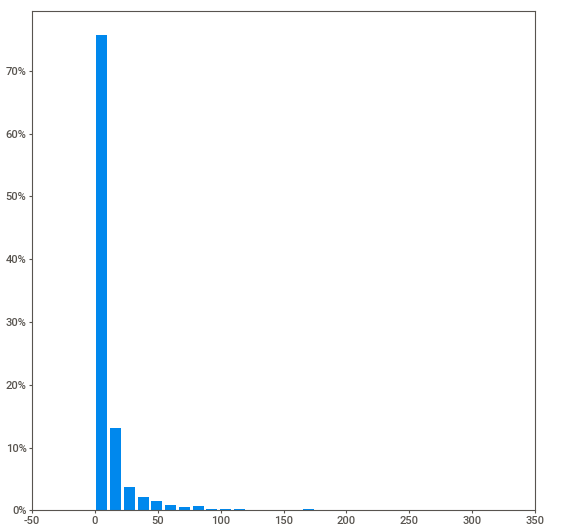
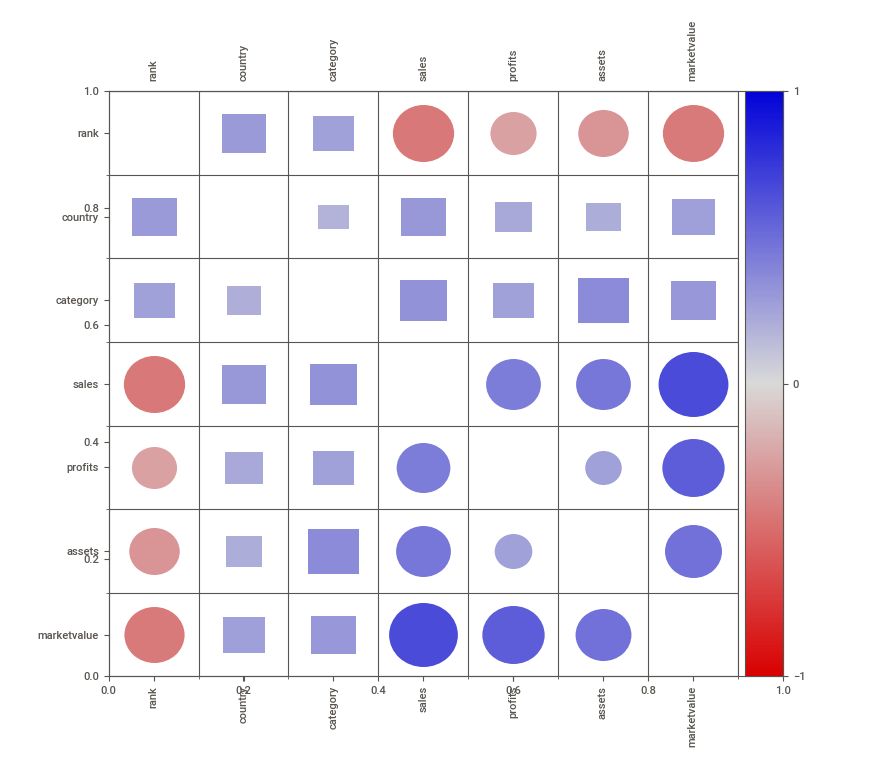
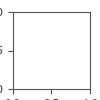

In [78]:
my_report.show_notebook() # para ver o html no notebook

In [77]:
my_report.show_html(  filepath='./SWEETVIZ_REPORT.html',
            open_browser=True,
            layout='widescreen',
            scale=None)
# gera o html e salva no diretorio local

Report ./SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
